# =====================================================================
# 00_EDA_EXPLORATORIO_BRONZE.ipynb
# Proyecto: Predicción de Ausentismo en Citas Médicas
# Objetivo: Identificar desbalance, anomalías y generar hallazgos para Feature Engineering
# =====================================================================

In [5]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Agregar la raíz del proyecto para importar la conexión
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.config import supabase

## 1. Extracción Paginada desde Supabase (bronze.citas_raw)

In [6]:
def cargar_datos_bronze():
    print(" Extrayendo datos desde la Capa Bronze en Supabase...")
    registros = []
    inicio = 0
    tamano_pagina = 1000
    while True:
        res = supabase.schema("bronze").table("citas_raw").select("*").range(inicio, inicio + tamano_pagina - 1).execute()
        datos = res.data
        if not datos:
            break
        registros.extend(datos)
        inicio += tamano_pagina
        if len(datos) < tamano_pagina:
            break
    df = pd.DataFrame(registros)
    print(f" Extracción exitosa: {len(df)} registros cargados.")
    return df

df_bronze = cargar_datos_bronze()


 Extrayendo datos desde la Capa Bronze en Supabase...
 Extracción exitosa: 110527 registros cargados.


## 2. Inspección de Estructura y Valores Nulos

In [7]:
print("---  INFORMACIÓN DEL DATAFRAME ---")
print(df_bronze.info())

print("\n---  VALORES NULOS Y DUPLICADOS ---")
print(f"Valores nulos por columna:\n{df_bronze.isnull().sum()}")
print(f"Registros duplicados totales: {df_bronze.duplicated().sum()}")

---  INFORMACIÓN DEL DATAFRAME ---
<class 'pandas.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   id                   110527 non-null  int64  
 1   patientid            110527 non-null  float64
 2   appointmentid        110527 non-null  int64  
 3   gender               110527 non-null  str    
 4   scheduledday         110527 non-null  str    
 5   appointmentday       110527 non-null  str    
 6   age                  110527 non-null  int64  
 7   neighbourhood        110527 non-null  str    
 8   scholarship          110527 non-null  int64  
 9   hipertension         110527 non-null  int64  
 10  diabetes             110527 non-null  int64  
 11  alcoholism           110527 non-null  int64  
 12  handcap              110527 non-null  int64  
 13  sms_received         110527 non-null  int64  
 14  no_show              110527 non-null  str   

## 3. Análisis de la Variable Objetivo (Desbalance de Clases)

C:\Users\yasel\AppData\Local\Temp\ipykernel_25608\1123199866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_bronze, x='no_show', palette='Set2')


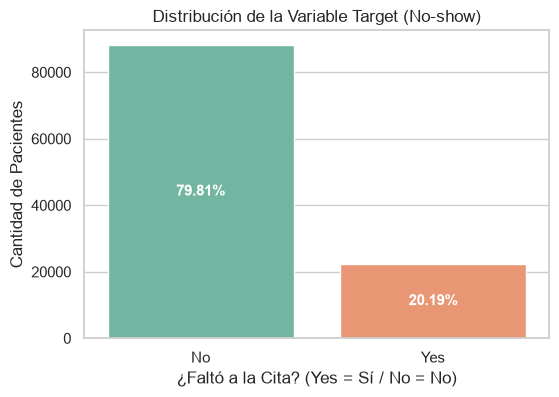


 HALLAZGO 1 (Desbalance de Clases):
- Aproximadamente el 80% de los pacientes SÍ asisten (No) y el 20% FALTA (Yes).
- Conclusión: No debemos usar Accuracy. Evaluaremos los modelos con RECALL y ROC-AUC.


In [8]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_bronze, x='no_show', palette='Set2')
plt.title('Distribución de la Variable Target (No-show)')
plt.xlabel('¿Faltó a la Cita? (Yes = Sí / No = No)')
plt.ylabel('Cantidad de Pacientes')

total = len(df_bronze)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=11, color='white', weight='bold')
plt.show()

print("\n HALLAZGO 1 (Desbalance de Clases):")
print("- Aproximadamente el 80% de los pacientes SÍ asisten (No) y el 20% FALTA (Yes).")
print("- Conclusión: No debemos usar Accuracy. Evaluaremos los modelos con RECALL y ROC-AUC.")

## 4. Análisis del Tiempo de Espera (Lead Time)

C:\Users\yasel\AppData\Local\Temp\ipykernel_25608\2151488187.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bronze, x='no_show', y='lead_time_eda', palette='Set2')


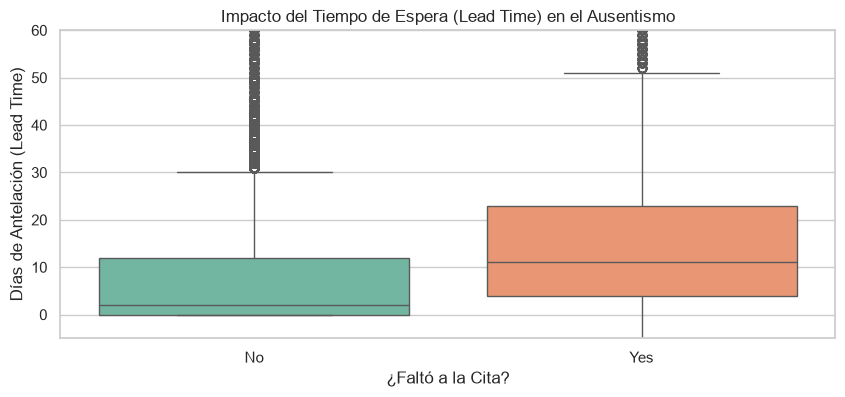


 HALLAZGO 2 (Justificación de Feature Engineering):
- Ausentismo en citas reservadas para el MISMO DÍA (Lead Time = 0): 4.65%
- Ausentismo en citas reservadas con 30+ DÍAS DE ANTICIPACIÓN: 32.59%
- Conclusión: 'lead_time' debe crearse obligatoriamente en la Capa Silver.


In [10]:
# Conversión temporal de prueba para el EDA
df_bronze['scheduled_dt'] = pd.to_datetime(df_bronze['scheduledday'], utc=True)
df_bronze['appointment_dt'] = pd.to_datetime(df_bronze['appointmentday'], utc=True)

# Cálculo correcto de días restando las fechas de calendario
df_bronze['lead_time_eda'] = (df_bronze['appointment_dt'].dt.date - df_bronze['scheduled_dt'].dt.date).apply(
    lambda x: x.days if pd.notnull(x) else 0
)

plt.figure(figsize=(10, 4))
sns.boxplot(data=df_bronze, x='no_show', y='lead_time_eda', palette='Set2')
plt.title('Impacto del Tiempo de Espera (Lead Time) en el Ausentismo')
plt.xlabel('¿Faltó a la Cita?')
plt.ylabel('Días de Antelación (Lead Time)')
plt.ylim(-5, 60)
plt.show()

# Comparación de ausentismo por días de espera
noshow_mismo_dia = df_bronze[df_bronze['lead_time_eda'] == 0]['no_show'].value_counts(normalize=True).get('Yes', 0) * 100
noshow_mas_30d = df_bronze[df_bronze['lead_time_eda'] >= 30]['no_show'].value_counts(normalize=True).get('Yes', 0) * 100

print(f"\n HALLAZGO 2 (Justificación de Feature Engineering):")
print(f"- Ausentismo en citas reservadas para el MISMO DÍA (Lead Time = 0): {noshow_mismo_dia:.2f}%")
print(f"- Ausentismo en citas reservadas con 30+ DÍAS DE ANTICIPACIÓN: {noshow_mas_30d:.2f}%")
print("- Conclusión: 'lead_time' debe crearse obligatoriamente en la Capa Silver.")

## 5. Detección de Inconsistencias Lógicas (Banderas de Calidad)

In [11]:
anomalias_edad = df_bronze[df_bronze['age'] < 0]
anomalias_lead = df_bronze[df_bronze['lead_time_eda'] < 0]

print("\n HALLAZGO 3 (Auditoría de Datos):")
print(f"- Registros con edad negativa: {len(anomalias_edad)}")
print(f"- Registros con fecha de cita anterior a la fecha de reserva: {len(anomalias_lead)}")
print("- Conclusión: Crear la bandera 'alerta_calidad_logica' en la Capa Silver para aislar estos registros.")


 HALLAZGO 3 (Auditoría de Datos):
- Registros con edad negativa: 1
- Registros con fecha de cita anterior a la fecha de reserva: 5
- Conclusión: Crear la bandera 'alerta_calidad_logica' en la Capa Silver para aislar estos registros.
